In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import pickle
import random
from tqdm import tqdm
from collections import defaultdict
from matplotlib.ticker import FuncFormatter
import math

# Signed Directed Gene Regulatory Network Analysis

This notebook processes gene regulatory network data from CSV files, cleans and merges them, builds a directed graph with node attributes, and performs detailed motif exploration (including configuration and Erdos-Renyi null models). In addition, it extracts and classifies 3-node motifs (triads) and submotifs (with a focus on the 030T type) and compares the real network with null models.

 ## 1. Loading and Cleaning the Data

We load three CSV files and keep only the essential columns. Then we replace the interaction types and confidence levels with standardized values.


In [41]:
# Read data from CSV files
reg_gen_data = pd.read_csv('../data/NetworkRegulatorGene.csv')
reg_reg_data = pd.read_csv('../data/NetworkRegulatorRegulator.csv')
reg_tu_data = pd.read_csv('../data/NetworkRegulatorTU.csv')

In [42]:
# Keep only necessary columns
cols = ['1)regulatorId', '4)regulatedId', '6)function', '7)confidenceLevel ']
reg_gen_data = reg_gen_data[cols]
reg_reg_data = reg_reg_data[cols]
reg_tu_data = reg_tu_data[cols]

In [43]:
# Set to 0 rows where the "6)function" column is NaN
reg_gen_data["6)function"] = reg_gen_data["6)function"].fillna("0")
reg_reg_data["6)function"] = reg_reg_data["6)function"].fillna("0")
reg_tu_data["6)function"]  = reg_tu_data["6)function"].fillna("0")

In [44]:
# Replace function values: '+' -> "1", '-' -> "-1", '-+' -> "0"
for df in [reg_gen_data, reg_reg_data, reg_tu_data]:
    df['6)function'] = df['6)function'].replace(['+'], "1")
    df['6)function'] = df['6)function'].replace(['-'], "-1")
    df['6)function'] = df['6)function'].replace(['-+'], "0")

In [45]:
# Replace confidence levels: 'C' -> "2", 'S' -> "1", 'W' -> "0"
for df in [reg_gen_data, reg_reg_data, reg_tu_data]:
    df['7)confidenceLevel '] = df['7)confidenceLevel '].replace(['C'], "2")
    df['7)confidenceLevel '] = df['7)confidenceLevel '].replace(['S'], "1")
    df['7)confidenceLevel '] = df['7)confidenceLevel '].replace(['W'], "0")

## 2. Building the network graph

A directed graph is created and nodes are added from each dataset. Node types are labeled as 'regulator', 'gene', or 'TU'. Then edges are added with attributes (function, confidence, and color).

In [46]:
# Create directed graph
G = nx.DiGraph()

# Add nodes from the regulator-regulator dataset
for node in reg_reg_data['1)regulatorId'].unique():
    G.add_node(str(node), type='regulator')
for node in reg_reg_data['4)regulatedId'].unique():
    G.add_node(str(node), type='regulator')

# Add nodes from the regulator-gene dataset
for node in reg_gen_data['1)regulatorId'].unique():
    G.add_node(str(node), type='regulator')
for node in reg_gen_data['4)regulatedId'].unique():
    G.add_node(str(node), type='gene')

# Add nodes from the regulator-TU dataset
for node in reg_tu_data['1)regulatorId'].unique():
    G.add_node(str(node), type='regulator')
for node in reg_tu_data['4)regulatedId'].unique():
    G.add_node(str(node), type='TU')

In [47]:
# Add edges for regulator-regulator dataset
for i in range(len(reg_reg_data)):
    edge1 = str(reg_reg_data.iloc[i]['1)regulatorId'])
    edge2 = str(reg_reg_data.iloc[i]['4)regulatedId'])
    function = reg_reg_data.iloc[i]['6)function']
    confidence = reg_reg_data.iloc[i]['7)confidenceLevel ']
    G.add_edge(edge1, edge2, function=function, confidence=confidence, color="chocolate")

In [48]:
# Add edges for regulator-gene dataset
for i in range(len(reg_gen_data)):
    edge1 = str(reg_gen_data.iloc[i]['1)regulatorId'])
    edge2 = str(reg_gen_data.iloc[i]['4)regulatedId'])
    function = reg_gen_data.iloc[i]['6)function']
    confidence = reg_gen_data.iloc[i]['7)confidenceLevel ']
    G.add_edge(edge1, edge2, function=function, confidence=confidence, color="yellowgreen")


In [49]:
# Add edges for regulator-TU dataset
for i in range(len(reg_tu_data)):
    edge1 = str(reg_tu_data.iloc[i]['1)regulatorId'])
    edge2 = str(reg_tu_data.iloc[i]['4)regulatedId'])
    function = reg_tu_data.iloc[i]['6)function']
    confidence = reg_tu_data.iloc[i]['7)confidenceLevel ']
    G.add_edge(edge1, edge2, function=function, confidence=confidence, color="olivedarb")

## 3. Basic Analysis and Graph Export

We save the graph (both as a pickle file and GraphML) and compute some basic network statistics on an undirected version of the network.

In [50]:
# Save the graph to a file
with open('network_ecoli.pickle', 'wb') as f:
    pickle.dump(G, f)
nx.write_graphml(G, 'network_ecoli.graphml')

In [51]:
# Convert G to undirected graph for basic analysis
D = nx.to_undirected(G)
print("Nodes:", nx.number_of_nodes(D))
print("Edges:", nx.number_of_edges(D))
print("Connected components:", nx.number_connected_components(D))

Nodes: 4628
Edges: 10891
Connected components: 19


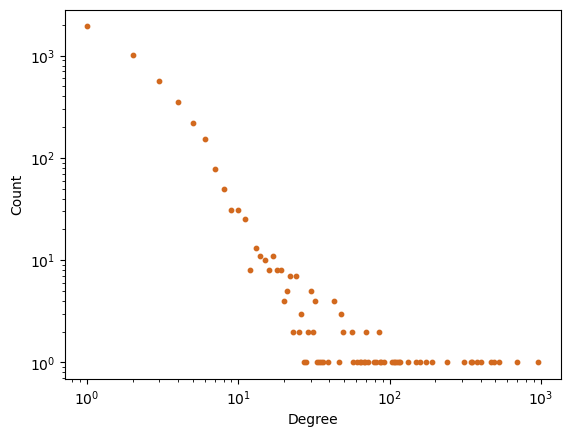

In [52]:
# Plot the degree distribution (log-log scale)
import collections
degree_sequence = sorted([d for n, d in D.degree()], reverse=True)
degreeCount = collections.Counter(degree_sequence)
deg, cnt = zip(*degreeCount.items())
plt.figure(dpi=100)
plt.scatter(deg, cnt, color='chocolate', s=10, marker="o")
plt.yscale('log')
plt.xscale('log')
plt.ylabel("Count")
plt.xlabel("Degree")
plt.show()

In [53]:
# Compute clustering coefficient and transitivity
print("Average clustering coefficient:", nx.average_clustering(D))
print("Transitivity index:", nx.transitivity(D))

Average clustering coefficient: 0.19272459743660067
Transitivity index: 0.008814002005469689


## 4. Motifs Exploration in the Real Network

We compute the triadic census for the directed network, remove motifs that are not 3-node motifs (003, 012, 102), and plot a histogram (using logarithmic scale).


In [54]:
motifs = nx.algorithms.triads.triadic_census(G)
for key in ['003', '012', '102']:
    del motifs[key]
print("3-nodes motifs:", motifs)
print("Total number of 3-nodes motifs:", sum(motifs.values()))


3-nodes motifs: {'021D': 1558708, '021U': 12673, '021C': 19240, '111D': 123, '111U': 4665, '030T': 4097, '030C': 0, '201': 2, '120D': 31, '120U': 589, '120C': 8, '210': 3, '300': 1}
Total number of 3-nodes motifs: 1600140


C:\Users\sofia\AppData\Local\Temp\ipykernel_30276\203714540.py:6: RuntimeWarning: divide by zero encountered in log
  plt.bar(motifs_names, np.log(motifs_counts), color='b', alpha=0.5)


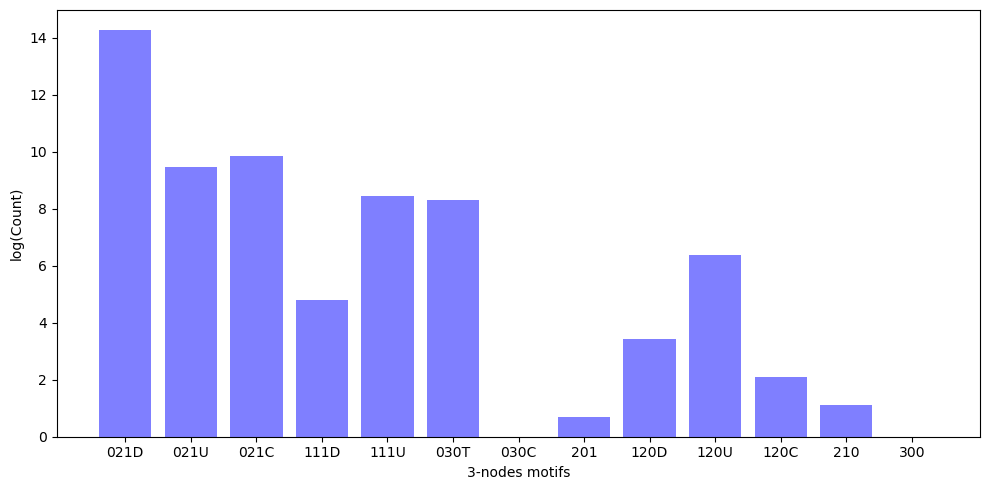

In [55]:
# Plot histogram of motifs (log scale)
motifs_names = list(motifs.keys())
motifs_counts = list(motifs.values())
np.save('motif_counts_original_net.npy', motifs_counts)
plt.figure(figsize=(10, 5))
plt.bar(motifs_names, np.log(motifs_counts), color='b', alpha=0.5)
plt.ylabel("log(Count)")
plt.xlabel("3-nodes motifs")
plt.tight_layout()
plt.show()

## 5. Configuration Model and Triadic Census

We compute the in-degree and out-degree sequences, create a directed configuration model, and then compute its triadic census.


In [56]:
in_degree_sequence = sorted([d for n, d in G.in_degree()], reverse=True)
out_degree_sequence = sorted([d for n, d in G.out_degree()], reverse=True)
G_config = nx.directed_configuration_model(in_degree_sequence, out_degree_sequence, create_using=nx.DiGraph())

3-nodes motifs in the configuration model: {'021D': 1302670, '021U': 8158, '021C': 80726, '111D': 769, '111U': 40473, '030T': 3794, '030C': 191, '201': 181, '120D': 55, '120U': 1350, '120C': 225, '210': 115, '300': 15}
Total number of 3-nodes motifs in configuration model: 1438722


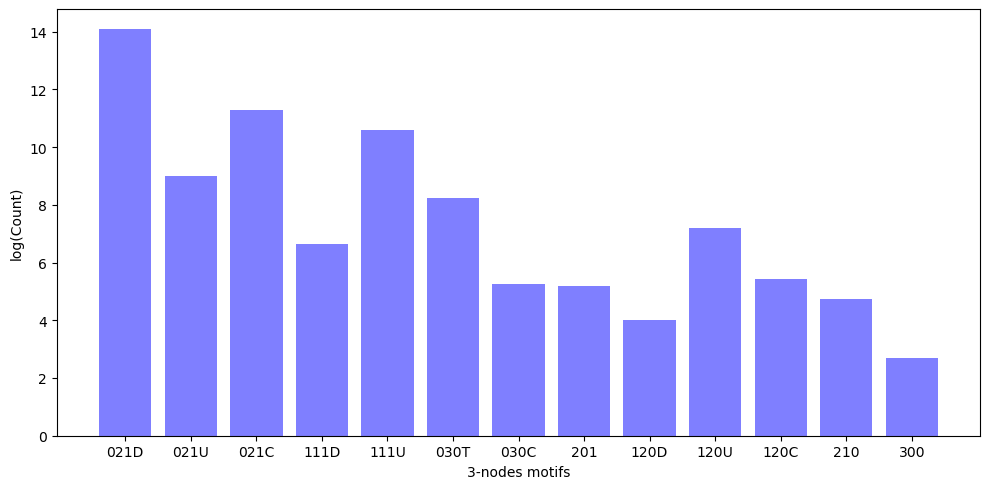

In [57]:
motifs_config = nx.algorithms.triads.triadic_census(G_config)

for key in ['003', '012', '102']:
    motifs_config.pop(key)

print("3-nodes motifs in the configuration model:", motifs_config)
print("Total number of 3-nodes motifs in configuration model:", sum(motifs_config.values()))

motifs_config_names = list(motifs_config.keys())
motifs_config_counts = list(motifs_config.values())

plt.figure(figsize=(10, 5))
plt.bar(motifs_config_names, np.log(motifs_config_counts), color='b', alpha=0.5)
plt.ylabel("log(Count)")
plt.xlabel("3-nodes motifs")
plt.tight_layout()
plt.show()

## 6. Z-Score: Config Model vs. Real Network 

 We generate multiple configuration models to compute the mean and standard deviation of motif counts and then compute the z-scores for the real network.


In [58]:
in_degree_sequence = sorted([d for n, d in G.in_degree()], reverse=True)
out_degree_sequence = sorted([d for n, d in G.out_degree()], reverse=True)

N = 10  # number of configuration models
motifs_config_all = np.zeros((N, 13))

for n in tqdm(range(N)):
    G_config = nx.directed_configuration_model(in_degree_sequence, out_degree_sequence, create_using=nx.DiGraph(), seed=random.randint(1, 1000))
    motifs_config = nx.algorithms.triads.triadic_census(G_config)
    for key in ['003', '012', '102']:
        motifs_config.pop(key)
    motifs_config_counts = np.array(list(motifs_config.values()))
    motifs_config_all[n, :] = motifs_config_counts
    
np.save("motifs_config_all.npy", motifs_config_all)

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [03:42<00:00, 22.25s/it]


In [59]:
motifs_config_all = np.load("motifs_config_all.npy")

motifs_config_mean = np.mean(motifs_config_all, axis=0)
motifs_config_std = np.std(motifs_config_all, axis=0)

print("Mean of motifs counts in configuration model:", motifs_config_mean)
print("Standard deviation of motifs counts in configuration model:", motifs_config_std)

z_scores = (np.array(motifs_counts) - motifs_config_mean) / motifs_config_std
print("Z-scores of the motifs counts:", z_scores)

Mean of motifs counts in configuration model: [1.2950327e+06 7.8897000e+03 8.2858600e+04 7.5280000e+02 4.0679800e+04
 4.0844000e+03 1.9810000e+02 1.9330000e+02 6.3600000e+01 1.3391000e+03
 2.3630000e+02 1.1240000e+02 1.4000000e+01]
Standard deviation of motifs counts in configuration model: [1.34785594e+04 1.24458869e+02 2.56147532e+03 7.20247180e+01
 3.25752976e+03 1.45004965e+02 1.87853666e+01 3.91766512e+01
 1.17575508e+01 1.13608494e+02 1.38567673e+01 1.55447740e+01
 6.14817046e+00]
Z-scores of the motifs counts: [ 19.5625729   38.43277743 -24.83670226  -8.74422029 -11.05586215
   0.08689358 -10.5454423   -4.88301052  -2.77268631  -6.60249926
 -16.47570426  -7.03773498  -2.11445016]


## 7. Comparison Plot: Real, Configuration Model, and ER Model

Next, we create bar plots to compare the motif counts for the real network, configuration model, and an Erdos-Renyi (ER) model.


C:\Users\sofia\AppData\Local\Temp\ipykernel_30276\1809258315.py:6: RuntimeWarning: divide by zero encountered in log
  bar1 = ax.bar(index, np.log(motifs_counts), bar_width, label='Real network', color='coral')


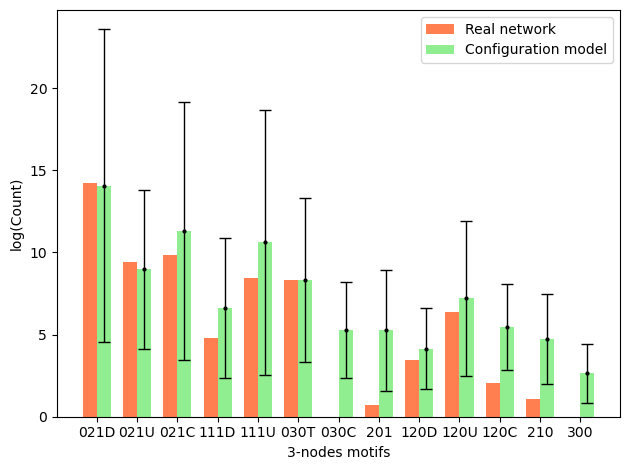

In [60]:
# Plot for real vs. configuration model
n_paths = len(motifs_counts)
fig, ax = plt.subplots()
bar_width = 0.35
index = np.arange(len(motifs_config_names))
bar1 = ax.bar(index, np.log(motifs_counts), bar_width, label='Real network', color='coral')
bar2 = ax.bar(index + bar_width, np.log(motifs_config_mean), bar_width, label='Configuration model', color='lightgreen')
ax.errorbar(index + bar_width, np.log(motifs_config_mean), yerr=np.log(motifs_config_std), fmt='o', color='black', capsize=4, markersize=2, elinewidth=1, capthick=1)
ax.set_xlabel('3-nodes motifs')
ax.set_ylabel('log(Count)')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(motifs_config_names)
ax.legend()
plt.tight_layout()
plt.show()

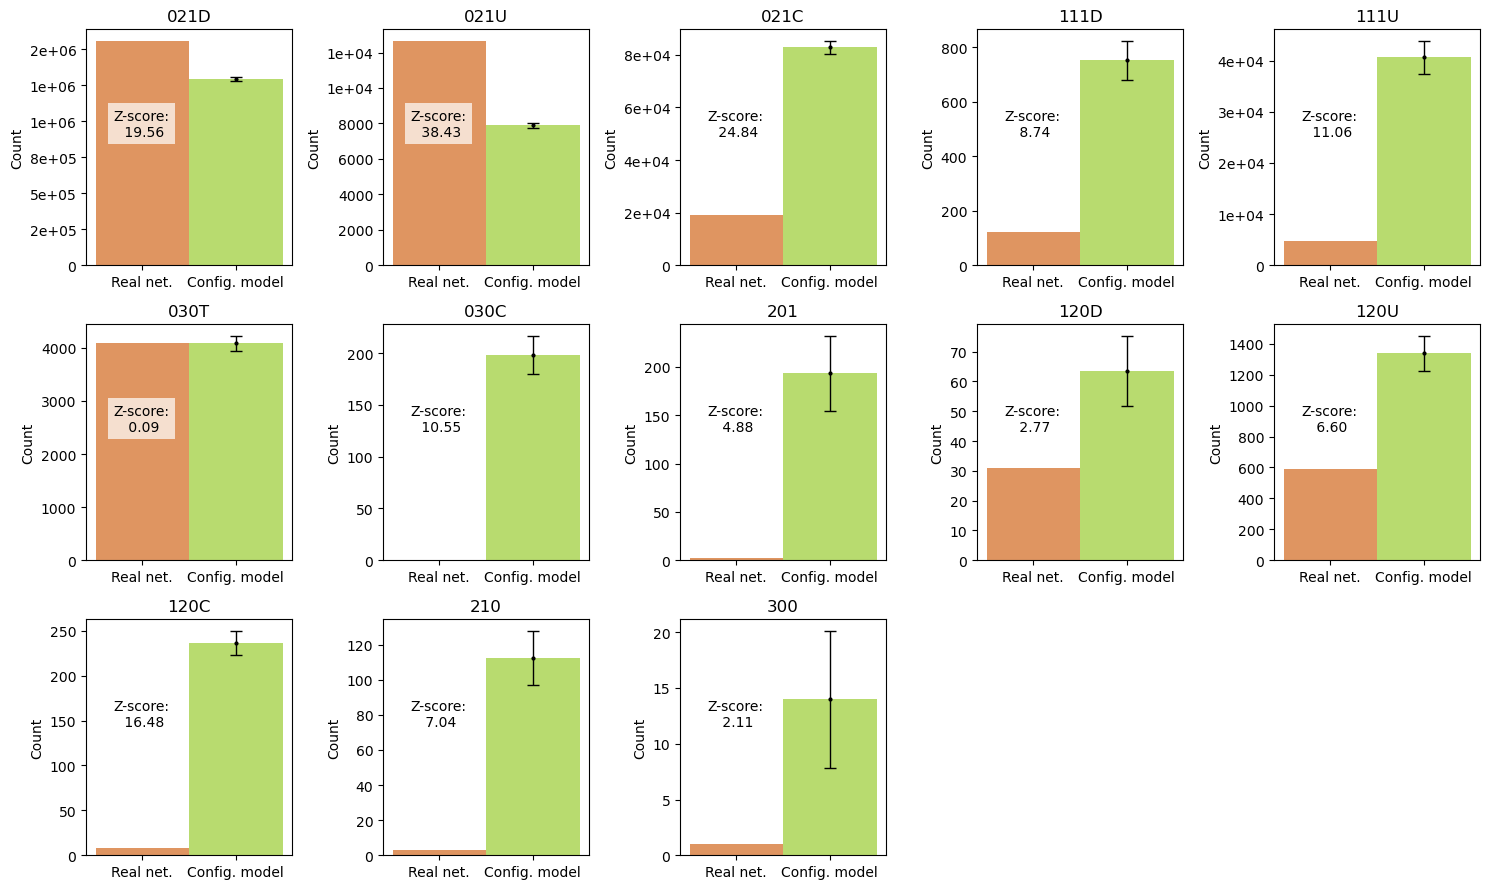

In [61]:
# Plot individual comparisons without log scale using subplots
fig, axs = plt.subplots(3, 5, figsize=(15, 9))
axs = axs.ravel()

def format_ticks(value, _):
    if value >= 1e4:
        return f'{value:.0e}'
    else:
        return f'{value:.0f}'
    
for i in range(len(motifs_config_names)):
    ax = axs[i]
    ax.bar(0, motifs_counts[i], bar_width, color='chocolate', alpha=0.7)
    ax.bar(bar_width, motifs_config_mean[i], bar_width, color='yellowgreen', alpha=0.7)
    ax.errorbar(bar_width, motifs_config_mean[i], yerr=motifs_config_std[i], fmt='o', color='black', capsize=4, markersize=2, elinewidth=1, capthick=1)
    ax.set_ylabel('Count')
    ax.set_xticks([0, bar_width])
    ax.set_xticklabels(['Real net.', 'Config. model'])
    
    for tick in ax.get_xticklabels():
        tick.set_rotation(0)
    ax.set_title(motifs_config_names[i])
    ax.yaxis.set_major_formatter(FuncFormatter(format_ticks))
    ax.text(0.27, 0.6, f'Z-score:\n {abs(z_scores[i]):.2f}', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

for i in range(len(motifs_config_names), 15):
    fig.delaxes(axs[i])

plt.tight_layout()
plt.show()

## 8. Extracting and Classifying Triads

We now remove self-loops and obtain the edge list from the undirected version of the network. Then we extract type 3 and type 2 motifs and classify them.


In [62]:
# Remove self loops and get edge list
G.remove_edges_from(nx.selfloop_edges(G))
D = nx.to_undirected(G)
edge_list = list(D.edges())
print("Number of edges after removing self loops:", len(edge_list))

Number of edges after removing self loops: 10755


### 8.1 Type 3 Motifs Extraction and Classification

Type 3 motifs include the following triad types: 030T, 030C, 120D, 120U, 120C, 210, 300.


In [63]:
num_type3_motifs = motifs["030T"] + motifs["030C"] + motifs["120D"] + motifs["120U"] + motifs["120C"] + motifs["210"] + motifs["300"]
type3_motifs = np.zeros((10*num_type3_motifs, 3), dtype=object)
k = 0

for edge in tqdm(edge_list):
    n1, n2 = edge
    neighbors_n1 = set(D.neighbors(n1))
    neighbors_n2 = set(D.neighbors(n2))
    common_neighbors = neighbors_n1.intersection(neighbors_n2)
    triads = [(n1, n2, n) for n in common_neighbors]
    num_triads = len(triads)

    if num_triads > 0:
        type3_motifs[k:k + num_triads] = triads
        k += num_triads

type3_motifs = type3_motifs[type3_motifs[:, 0] != 0]

type3_df = pd.DataFrame(type3_motifs, columns=["Node 1", "Node 2", "Node 3"])
type3_df['frozenset'] = type3_df.apply(lambda row: frozenset(row), axis=1)
type3_df = type3_df.drop_duplicates(subset='frozenset')
type3_df = type3_df.drop(columns='frozenset')

print(len(type3_df), num_type3_motifs)

100%|██████████| 10755/10755 [00:00<00:00, 17297.89it/s]


4729 4729


#### Type 3 Triad Classification

We loop over each triad and use NetworkX’s `triad_type` function to classify it.


In [64]:
# create a dictionary to store the type of each triad
triad_types3_nodes = {"030T": [], "030C": [], "120D": [], "120U": [], "120C": [], "210": [], "300": []}
triad_type3_triads = {"030T": [], "030C": [], "120D": [], "120U": [], "120C": [], "210": [], "300": []}

# loop over all the triads
for i in tqdm(range(len(type3_df))):
    triad = type3_df.iloc[i]
    n1 = triad["Node 1"]
    n2 = triad["Node 2"]
    n3 = triad["Node 3"]

    # Create a subgraph and make a deep copy of it
    subgraph = G.subgraph([n1, n2, n3]).copy()

    # use networkx function to get the type of triad
    triad_type = nx.triad_type(subgraph)

    # store the type of triad
    triad_types3_nodes[triad_type].append(n1)
    triad_types3_nodes[triad_type].append(n2)
    triad_types3_nodes[triad_type].append(n3)

    # store the triad
    triad_type3_triads[triad_type].append(tuple(triad))

# remove duplicates
for key in triad_types3_nodes.keys():
    triad_types3_nodes[key] = set(triad_types3_nodes[key])

for key in triad_type3_triads.keys():
    triad_type3_triads[key] = set(triad_type3_triads[key])

# print the number of nodes in each type of triad
for key in triad_types3_nodes.keys():
    print(key, len(triad_types3_nodes[key]), "nodes")
print("\n")
# print the number of each type of triad
for key in triad_type3_triads.keys():
    print(key, len(triad_type3_triads[key]), "triads")

# sum all types of triads
total_type3_nodes = sum([len(triad_types3_nodes[key]) for key in triad_types3_nodes.keys()])
total_type3_triads = sum([len(triad_type3_triads[key]) for key in triad_type3_triads.keys()])

print()
print("Total type 3 triads", total_type3_triads, num_type3_motifs)

100%|██████████| 4729/4729 [00:03<00:00, 1505.80it/s]

030T 1664 nodes
030C 0 nodes
120D 34 nodes
120U 482 nodes
120C 18 nodes
210 7 nodes
300 3 nodes


030T 4097 triads
030C 0 triads
120D 31 triads
120U 589 triads
120C 8 triads
210 3 triads
300 1 triads

Total type 3 triads 4729 4729


 ### 8.2 Type 2 Motifs Extraction and Classification

We extract type 2 motifs (021D, 021U, 021C, 111D, 111U, 201) and classify them similarly.


In [65]:
# Now do the same for type 2 motifs
num_type2_motifs = motifs["021D"] + motifs["021U"] + motifs["021C"] + motifs["111D"] + motifs["111U"] + motifs["201"]

type2_motifs = np.zeros((3*num_type2_motifs, 3), dtype=object)

k = 0
for edge in tqdm(edge_list):
    n1 = edge[0]
    n2 = edge[1]

    # get the neighbors of n1 and n2
    neighbors_n1 = set(D.neighbors(n1))
    neighbors_n2 = set(D.neighbors(n2))

    # get the common neighbors of n1 and n2
    common_neighbors = neighbors_n1.intersection(neighbors_n2)

    # the triads will be composed by node 1, node 2 and the neighbors of node 1 and 2 when they are NOT common if the nodes are not repeated
    triads = [(n1, n2, n) for n in neighbors_n1.union(neighbors_n2) if n not in common_neighbors and n != n1 and n != n2]

    # add the triads to the array of type e motifs
    num_triads = len(triads)
    if num_triads > 0:
        type2_motifs[k:k + num_triads] = triads
        k += num_triads

# remove empty rows
type2_motifs = type2_motifs[type2_motifs[:, 0] != 0]

# remove duplicated triads by sorting the columns and removing duplicates
type2_df = pd.DataFrame(type2_motifs, columns=["Node 1", "Node 2", "Node 3"]) # convert to pandas dataframe
# Convert each row to a frozenset
type2_df['frozenset'] = type2_df.apply(lambda row: frozenset(row), axis=1)

# Remove duplicates
type2_df = type2_df.drop_duplicates(subset='frozenset')
# Drop the 'frozenset' column
type2_df = type2_df.drop(columns='frozenset')

print(len(type2_df), num_type2_motifs)

100%|██████████| 10755/10755 [00:02<00:00, 3708.28it/s]


1595411 1595411


#### Type 2 Triad Classification

In [66]:
# Obtain the types of motifs of each triad
# I will loop over all the triads and check which type of triad it is in the directed real network

# create a dictionary to store the type of each triad
triad_types2_nodes = {"021D": [], "021U": [], "021C": [], "111D": [], "111U": [], "201": []}
triad_type2_triads = {"021D": [], "021U": [], "021C": [], "111D": [], "111U": [], "201": []}

# loop over all the triads
for i in tqdm(range(len(type2_df))):
    triad = type2_df.iloc[i]
    n1 = triad["Node 1"]
    n2 = triad["Node 2"]
    n3 = triad["Node 3"]

    # Create a subgraph and make a deep copy of it
    subgraph = G.subgraph([n1, n2, n3]).copy()

    # use networkx function to get the type of triad
    triad_type = nx.triad_type(subgraph)

    # store the type of triad
    triad_types2_nodes[triad_type].append(n1)
    triad_types2_nodes[triad_type].append(n2)
    triad_types2_nodes[triad_type].append(n3)

    # store the triad
    triad_type2_triads[triad_type].append(tuple(triad))

# remove duplicates
for key in triad_types2_nodes.keys():
    triad_types2_nodes[key] = set(triad_types2_nodes[key])

for key in triad_type2_triads.keys():
    triad_type2_triads[key] = set(triad_type2_triads[key])

# print the number of nodes in each type of triad
for key in triad_types2_nodes.keys():
    print(key, len(triad_types2_nodes[key]), "nodes")
print("\n")
# print the number of each type of triad
for key in triad_type2_triads.keys():
    print(key, len(triad_type2_triads[key]), "triads")

# sum all types of triads
total_type2_nodes = sum([len(triad_types2_nodes[key]) for key in triad_types2_nodes.keys()])
total_type2_triads = sum([len(triad_type2_triads[key]) for key in triad_type2_triads.keys()])

print("Total type 2 triads", total_type2_triads, num_type2_motifs)

100%|██████████| 1595411/1595411 [24:51<00:00, 1070.02it/s] 

021D 4614 nodes
021U 2215 nodes
021C 3751 nodes
111D 72 nodes
111U 2783 nodes
201 6 nodes


021D 1558708 triads
021U 12673 triads
021C 19240 triads
111D 123 triads
111U 4665 triads
201 2 triads
Total type 2 triads 1595411 1595411


## 9. Submotif Classification for 030T Triads

 Here we focus on classifying the submotifs of the 030T type. The submotif types (a–h) are determined by the signs (function attribute) of the edges in each triad.

In [68]:
triads030T = triad_type3_triads["030T"]
submotifs030T_real = {"a": 0, "b": 0, "c": 0, "d": 0, "e": 0, "f": 0, "g": 0, "h": 0}
for triad in triads030T:
    n1, n2, n3 = triad
    # Determine edge directions and count occurrences
    u1 = u2 = u3 = 0
    if G.has_edge(n1, n2):
        edge1_ = G[n1][n2]
        u1 += 1
    else:
        edge1_ = G[n2][n1]
        u2 += 1
    if G.has_edge(n2, n3):
        edge2_ = G[n2][n3]
        u2 += 1
    else:
        edge2_ = G[n3][n2]
        u3 += 1
    if G.has_edge(n1, n3):
        edge3_ = G[n1][n3]
        u1 += 1
    else:
        edge3_ = G[n3][n1]
        u3 += 1
    # (Optional heuristic reordering code; preserved from your original)
    if u1 == 2:
        if u2 == 1 and u3 == 0:
            edge3, edge2, edge1 = edge1_, edge3_, edge2_
        elif u2 == 0 and u3 == 1:
            edge1, edge2, edge3 = edge3_, edge2_, edge3_
    elif u1 == 1:
        if u2 == 2 and u3 == 0:
            edge3, edge2, edge1 = edge1_, edge3_, edge2_
        elif u2 == 0 and u3 == 2:
            edge1, edge2, edge3 = edge2_, edge1_, edge3_
    elif u1 == 0:
        if u2 == 2 and u3 == 1:
            edge1, edge2, edge3 = edge1_, edge3_, edge2_
        elif u2 == 1 and u3 == 2:
            edge1, edge2, edge3 = edge3_, edge1_, edge2_
    # Determine the sign of each edge (if available)
    signs = []
    certainty = [edge1_["confidence"], edge2_["confidence"], edge3_["confidence"]]
    if "function" in edge1 and (certainty[0] in ["C ", "S "]):
        try:
            signs.append(int(edge1["function"]))
        except:
            print(edge1["function"])
    if "function" in edge2 and (certainty[1] in ["C ", "S "]):
        try:
            signs.append(int(edge2["function"]))
        except:
            print(edge2["function"])
    if "function" in edge3 and (certainty[2] in ["C ", "S "]):
        try:
            signs.append(int(edge3["function"]))
        except:
            print(edge3["function"])
    if len(signs) == 3:
        if signs[0] == 1 and signs[1] == 1 and signs[2] == 1:
            submotifs030T_real["a"] += 1
        elif signs[0] == -1 and signs[1] == -1 and signs[2] == -1:
            submotifs030T_real["b"] += 1
        elif signs[0] == 1 and signs[1] == 1 and signs[2] == -1:
            submotifs030T_real["c"] += 1
        elif signs[0] == 1 and signs[1] == -1 and signs[2] == -1:
            submotifs030T_real["d"] += 1
        elif signs[0] == 1 and signs[1] == -1 and signs[2] == 1:
            submotifs030T_real["e"] += 1
        elif signs[0] == -1 and signs[1] == 1 and signs[2] == 1:
            submotifs030T_real["f"] += 1
        elif signs[0] == -1 and signs[1] == -1 and signs[2] == 1:
            submotifs030T_real["g"] += 1
        elif signs[0] == -1 and signs[1] == 1 and signs[2] == -1:
            submotifs030T_real["h"] += 1
    elif len(signs) < 3:
        pass
print(submotifs030T_real)

{'a': 333, 'b': 194, 'c': 40, 'd': 147, 'e': 147, 'f': 38, 'g': 57, 'h': 186}


## 10. Normalizing and Plotting Submotif Frequencies

The submotif counts for 030T are normalized and compared with those from configuration models (null models). Z-scores are computed and a bar plot is generated.


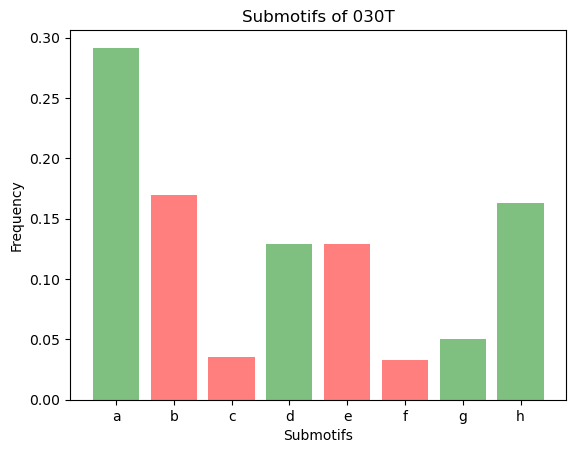

In [69]:
colors = {"a": "green", "b": "red", "c": "red", "d": "green", "e": "red", "f": "red", "g": "green", "h": "green"}
total = sum(submotifs030T_real.values())
submotifs030T_real = {k: v/total for k, v in submotifs030T_real.items()}
plt.figure()
plt.bar(submotifs030T_real.keys(), submotifs030T_real.values(), alpha=0.5, color=[colors[k] for k in submotifs030T_real.keys()])
plt.xlabel("Submotifs")
plt.ylabel("Frequency")
plt.title("Submotifs of 030T")
plt.show()


## 11. Signed Directed Configurational Model and ER Null Model

 We define functions for creating subgraphs (positive, negative, neutral), building a directed configuration model that preserves the sign, and finally combine them. We also generate Erdos-Renyi networks that match the densities of the real network.


In [70]:
def positive_net(G):
    """Return subgraph with only positive interactions."""
    G_pos = nx.DiGraph()
    for u, v, data in G.edges(data=True):
        if "function" in data and data["function"] == '1':
            G_pos.add_edge(u, v, function=1)
    return G_pos

def negative_net(G):
    """Return subgraph with only negative interactions."""
    G_neg = nx.DiGraph()
    for u, v, data in G.edges(data=True):
        if "function" in data and data["function"] == '-1':
            G_neg.add_edge(u, v, function=-1)
    return G_neg

def neutral_net(G):
    """Return subgraph with only neutral interactions."""
    G_neu = nx.DiGraph()
    for u, v, data in G.edges(data=True):
        if "function" in data and data["function"] == '0':
            G_neu.add_edge(u, v, function=0)
    return G_neu

def directed_config_model(G):
    """
    Create a directed configuration model that preserves the in- and out-degree sequences.
    Assumes a uniform function type across edges.
    """
    functions = set(data["function"] for _, _, data in G.edges(data=True) if "function" in data)
    type_net = functions.pop()  # representative value
    in_degree_sequence = sorted([d for n, d in G.in_degree()], reverse=True)
    out_degree_sequence = sorted([d for n, d in G.out_degree()], reverse=True)
    G_config = nx.directed_configuration_model(in_degree_sequence, out_degree_sequence, create_using=nx.DiGraph())
    for u, v, data in G_config.edges(data=True):
        G_config[u][v]["function"] = str(type_net)
    return G_config

print("Number of edges in G:", nx.number_of_edges(G))
G_pos = positive_net(G)
G_neg = negative_net(G)
G_neu = neutral_net(G)
print("\nNumber of edges in G_pos:", nx.number_of_edges(G_pos))
print("Number of edges in G_neg:", nx.number_of_edges(G_neg))
print("Number of edges in G_neu:", nx.number_of_edges(G_neu))
print("Sum of edges in G_pos, G_neg, G_neu:", nx.number_of_edges(G_pos) + nx.number_of_edges(G_neg) + nx.number_of_edges(G_neu))
G_pos_config = directed_config_model(G_pos)
G_neg_config = directed_config_model(G_neg)
G_neu_config = directed_config_model(G_neu)
G_all = nx.compose(G_pos_config, G_neg_config)
G_all = nx.compose(G_all, G_neu_config)
print("\nNumber of edges in G_all:", nx.number_of_edges(G_all))
functions_in_G_all = set(data["function"] for _, _, data in G_all.edges(data=True) if "function" in data)
print("Unique function values in G_all:", functions_in_G_all)

def create_directed_signed_config_model(G):
    G_pos = positive_net(G)
    G_neg = negative_net(G)
    G_neu = neutral_net(G)
    G_pos_config = directed_config_model(G_pos)
    G_neg_config = directed_config_model(G_neg)
    G_neu_config = directed_config_model(G_neu)
    G_all = nx.compose(G_pos_config, G_neg_config)
    G_all = nx.compose(G_all, G_neu_config)
    return G_all

Number of edges in G: 10772

Number of edges in G_pos: 4956
Number of edges in G_neg: 5379
Number of edges in G_neu: 437
Sum of edges in G_pos, G_neg, G_neu: 10772

Number of edges in G_all: 10044
Unique function values in G_all: {'-1', '1', '0'}


In [71]:
nodes = nx.number_of_nodes(G)
G_pos = positive_net(G)
edges_pos = nx.number_of_edges(G_pos)
G_neg = negative_net(G)
edges_neg = nx.number_of_edges(G_neg)
G_neu = neutral_net(G)
edges_neu = nx.number_of_edges(G_neu)
density_pos = edges_pos / (nodes * (nodes - 1))
density_neg = edges_neg / (nodes * (nodes - 1))
density_neu = edges_neu / (nodes * (nodes - 1))
print("Density of positive edges:", density_pos)
print("Density of negative edges:", density_neg)
print("Density of neutral edges:", density_neu)

Density of positive edges: 0.00023144001454018621
Density of negative edges: 0.0002511936719555411
Density of neutral edges: 2.0407442767163312e-05


In [72]:
N = 10
motifs_er_all = np.zeros((N, 13))
for n in tqdm(range(N)):
    G_er_pos = nx.erdos_renyi_graph(nodes, density_pos, directed=True)
    for u, v, data in G_er_pos.edges(data=True):
        G_er_pos[u][v]["function"] = 1
    G_er_neg = nx.erdos_renyi_graph(nodes, density_neg, directed=True)
    for u, v, data in G_er_neg.edges(data=True):
        G_er_neg[u][v]["function"] = -1
    G_er_neu = nx.erdos_renyi_graph(nodes, density_neu, directed=True)
    for u, v, data in G_er_neu.edges(data=True):
        G_er_neu[u][v]["function"] = 0
    G_er_all = nx.compose(G_er_pos, G_er_neg)
    G_er_all = nx.compose(G_er_all, G_er_neu)
    motifs_er = nx.algorithms.triads.triadic_census(G_er_all)
    for key in ['003', '012', '102']:
        del motifs_er[key]
    motifs_er_counts = np.array(list(motifs_er.values()))
    motifs_er_all[n, :] = motifs_er_counts
np.save("motifs_er_all_signed.npy", motifs_er_all)

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [02:04<00:00, 12.48s/it]


In [73]:
motifs_er_all = np.load("motifs_er_all_signed.npy")
motifs_counts = np.load("motif_counts_original_net.npy")
motifs_er_mean = np.mean(motifs_er_all, axis=0)
motifs_er_std = np.std(motifs_er_all, axis=0)
print("Mean of motifs counts in ER model:", motifs_er_mean)
print("Standard deviation of motifs counts in ER model:", motifs_er_std)
z_scores_er = (np.array(motifs_counts) - motifs_er_mean) / motifs_er_std
print("Z-scores of the motifs counts:", z_scores_er)

Mean of motifs counts in ER model: [1.25268e+04 1.25413e+04 2.50710e+04 8.90000e+00 1.32000e+01 1.45000e+01
 4.50000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
 0.00000e+00]
Standard deviation of motifs counts in ER model: [313.40542433 355.31761848 649.49965358   6.23618473  10.4
   4.00624512   2.29128785   0.           0.           0.
   0.           0.           0.        ]
Z-scores of the motifs counts: [ 4.93348577e+03  3.70654291e-01 -8.97767992e+00  1.82964432e+01
  4.47288462e+02  1.01903400e+03 -1.96396101e+00             inf
             inf             inf             inf             inf
             inf]


C:\Users\sofia\AppData\Local\Temp\ipykernel_30276\1185345770.py:7: RuntimeWarning: divide by zero encountered in divide
  z_scores_er = (np.array(motifs_counts) - motifs_er_mean) / motifs_er_std


#### Configuration Model Motif Counts

We generate multiple directed signed configuration models and compute the motif counts.


In [74]:
N = 10
motifs_config_all = np.zeros((N, 13))
for n in tqdm(range(N)):
    G_all_config = create_directed_signed_config_model(G)
    motifs_config = nx.algorithms.triads.triadic_census(G_all_config)
    for key in ['003', '012', '102']:
        motifs_config.pop(key)
    motifs_config_counts = np.array(list(motifs_config.values()))
    motifs_config_all[n, :] = motifs_config_counts
np.save("motifs_config_all_signed.npy", motifs_config_all)

100%|██████████| 10/10 [03:55<00:00, 23.56s/it]


In [75]:
motifs_config_all = np.load("motifs_config_all_signed.npy")
motifs_counts = np.load("motif_counts_original_net.npy")
motifs_config_mean = np.mean(motifs_config_all, axis=0)
motifs_config_std = np.std(motifs_config_all, axis=0)
print("Mean of motifs counts in configuration model:", motifs_config_mean)
print("Standard deviation of motifs counts in configuration model:", motifs_config_std)
z_scores = (np.array(motifs_counts) - motifs_config_mean) / motifs_config_std
print("Z-scores of the motifs counts:", z_scores)

Mean of motifs counts in configuration model: [1.3696392e+06 8.2488000e+03 7.6992400e+04 8.3150000e+02 5.1773500e+04
 6.3046000e+03 2.5040000e+02 2.9170000e+02 1.0760000e+02 2.5203000e+03
 3.6830000e+02 2.0920000e+02 2.5300000e+01]
Standard deviation of motifs counts in configuration model: [1.10500338e+04 6.51226535e+01 4.27311210e+03 8.28785256e+01
 2.94160739e+03 3.14449742e+02 3.80504928e+01 3.59167092e+01
 2.02247373e+01 2.61216405e+02 2.70408950e+01 2.29076406e+01
 8.00062498e+00]
Z-scores of the motifs counts: [ 17.11024633  67.93642092 -13.51530187  -8.54865594 -16.01454366
  -7.02051777  -6.58072949  -8.06588372  -3.78744103  -7.39348665
 -13.32426314  -9.00136348  -3.03726272]


#### Comparison Plot: Real, Config Model, and ER Model

A composite bar plot is produced comparing the three models.

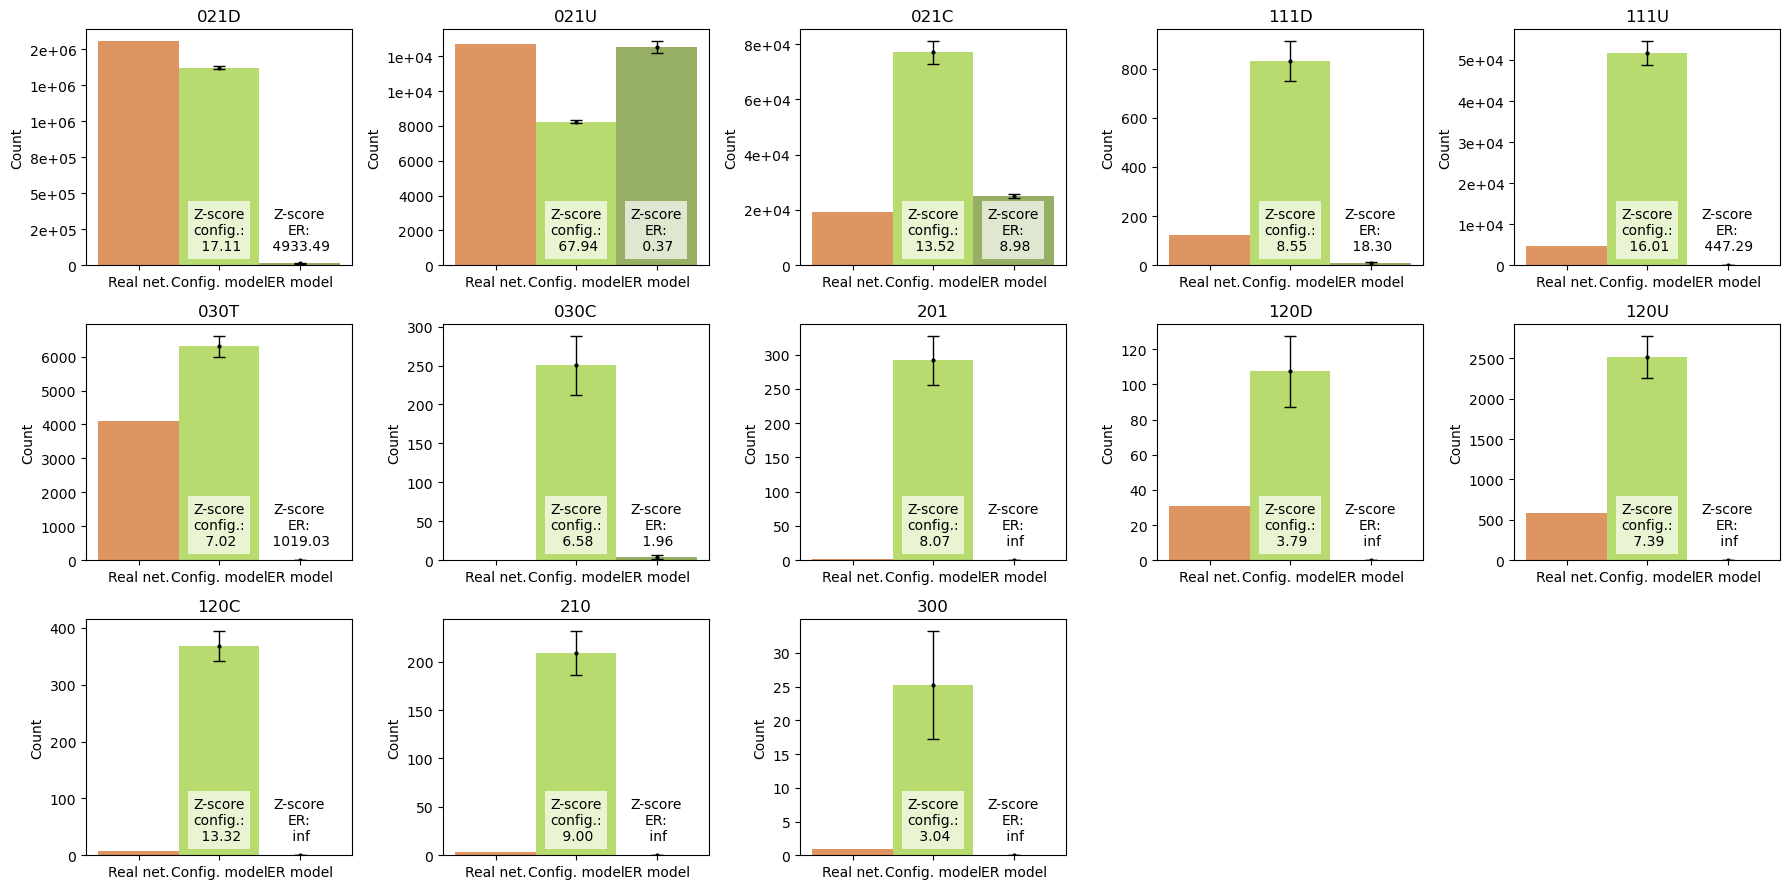

In [77]:
fig, axs = plt.subplots(3, 5, figsize=(18, 9))
axs = axs.ravel()
def format_ticks(value, _):
    if value >= 1e4:
        return f'{value:.0e}'
    else:
        return f'{value:.0f}'
bar_width = 0.35
for i in range(len(motifs_config_names)):
    ax = axs[i]
    ax.bar(0, motifs_counts[i], bar_width, color='chocolate', alpha=0.7)
    ax.bar(bar_width, motifs_config_mean[i], bar_width, color='yellowgreen', alpha=0.7)
    ax.errorbar(bar_width, motifs_config_mean[i], yerr=motifs_config_std[i], fmt='o', color='black', capsize=4, markersize=2, elinewidth=1, capthick=1)
    ax.bar(2*bar_width, motifs_er_mean[i], bar_width, color='olivedrab', alpha=0.7)
    ax.errorbar(2*bar_width, motifs_er_mean[i], yerr=motifs_er_std[i], fmt='o', color='black', capsize=4, markersize=2, elinewidth=1, capthick=1)
    ax.set_ylabel('Count')
    ax.set_xticks([0, bar_width, 2*bar_width])
    ax.set_xticklabels(['Real net.', 'Config. model', 'ER model'])
    for tick in ax.get_xticklabels():
        tick.set_rotation(0)
    ax.set_title(motifs_config_names[i])
    ax.yaxis.set_major_formatter(FuncFormatter(format_ticks))
    ax.text(0.5, 0.15, f'Z-score\nconfig.:\n {abs(z_scores[i]):.2f}', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    ax.text(0.8, 0.15, f'Z-score\nER:\n {abs(z_scores_er[i]):.2f}', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
for i in range(len(motifs_config_names), 15):
    fig.delaxes(axs[i])
plt.tight_layout()
plt.show()

## 12. Obtaining Triads from Configuration Model Networks and Submotif Classification

In [78]:
def obtain_type3_triads(G):
    """
    Obtain type 3 triads from network G.
    """
    G.remove_edges_from(nx.selfloop_edges(G))
    D = nx.to_undirected(G)
    edge_list = list(D.edges())
    num_type3_motifs = motifs["030T"] + motifs["030C"] + motifs["120D"] + motifs["120U"] + motifs["120C"] + motifs["210"] + motifs["300"]
    type3_motifs = np.zeros((10*num_type3_motifs, 3), dtype=object)
    k = 0
    for edge in edge_list:
        n1, n2 = edge
        neighbors_n1 = set(D.neighbors(n1))
        neighbors_n2 = set(D.neighbors(n2))
        common_neighbors = neighbors_n1.intersection(neighbors_n2)
        triads = [(n1, n2, n) for n in common_neighbors]
        num_triads = len(triads)
        if num_triads > 0:
            type3_motifs[k:k + num_triads] = triads
            k += num_triads
    type3_motifs = type3_motifs[type3_motifs[:, 0] != 0]
    type3_df = pd.DataFrame(type3_motifs, columns=["Node 1", "Node 2", "Node 3"])
    type3_df['frozenset'] = type3_df.apply(lambda row: frozenset(row), axis=1)
    type3_df = type3_df.drop_duplicates(subset='frozenset')
    type3_df = type3_df.drop(columns='frozenset')
    triad_types3_nodes = {"030T": [], "030C": [], "120D": [], "120U": [], "120C": [], "210": [], "300": []}
    triad_type3_triads = {"030T": [], "030C": [], "120D": [], "120U": [], "120C": [], "210": [], "300": []}
    for i in range(len(type3_df)):
        triad = type3_df.iloc[i]
        n1, n2, n3 = triad["Node 1"], triad["Node 2"], triad["Node 3"]
        subgraph = G.subgraph([n1, n2, n3]).copy()
        triad_type = nx.triad_type(subgraph)
        triad_types3_nodes[triad_type].extend([n1, n2, n3])
        triad_type3_triads[triad_type].append(tuple(triad))
    for key in triad_type3_triads:
        triad_type3_triads[key] = set(triad_type3_triads[key])
    return triad_type3_triads

def submotif_classification(G):
    """
    Classify submotifs (030T) from network G.
    """
    triad_type3_triads = obtain_type3_triads(G)
    triads030T = triad_type3_triads["030T"]
    submotifs030T = {"a": 0, "b": 0, "c": 0, "d": 0, "e": 0, "f": 0, "g": 0, "h": 0}
    for triad in triads030T:
        n1, n2, n3 = triad
        u1 = u2 = u3 = 0
        if G.has_edge(n1, n2):
            edge1_ = G[n1][n2]
            u1 += 1
        else:
            edge1_ = G[n2][n1]
            u2 += 1
        if G.has_edge(n2, n3):
            edge2_ = G[n2][n3]
            u2 += 1
        else:
            edge2_ = G[n3][n2]
            u3 += 1
        if G.has_edge(n1, n3):
            edge3_ = G[n1][n3]
            u1 += 1
        else:
            edge3_ = G[n3][n1]
            u3 += 1
        if u1 == 2:
            if u2 == 1 and u3 == 0:
                edge3, edge2, edge1 = edge1_, edge3_, edge2_
            elif u2 == 0 and u3 == 1:
                edge1, edge2, edge3 = edge3_, edge1_, edge2_
        elif u1 == 1:
            if u2 == 2 and u3 == 0:
                edge3, edge2, edge1 = edge1_, edge3_, edge2_
            elif u2 == 0 and u3 == 2:
                edge1, edge2, edge3 = edge2_, edge1_, edge3_
        elif u1 == 0:
            if u2 == 2 and u3 == 1:
                edge1, edge2, edge3 = edge1_, edge3_, edge2_
            elif u2 == 1 and u3 == 2:
                edge1, edge2, edge3 = edge3_, edge1_, edge2_
        signs = []
        if "function" in edge1:
            try:
                signs.append(int(edge1["function"]))
            except:
                print(edge1["function"])
        if "function" in edge2:
            try:
                signs.append(int(edge2["function"]))
            except:
                print(edge2["function"])
        if "function" in edge3:
            try:
                signs.append(int(edge3["function"]))
            except:
                print(edge3["function"])
        if len(signs) == 3:
            if signs[0] == 1 and signs[1] == 1 and signs[2] == 1:
                submotifs030T["a"] += 1
            elif signs[0] == -1 and signs[1] == -1 and signs[2] == -1:
                submotifs030T["b"] += 1
            elif signs[0] == 1 and signs[1] == 1 and signs[2] == -1:
                submotifs030T["c"] += 1
            elif signs[0] == 1 and signs[1] == -1 and signs[2] == -1:
                submotifs030T["d"] += 1
            elif signs[0] == 1 and signs[1] == -1 and signs[2] == 1:
                submotifs030T["e"] += 1
            elif signs[0] == -1 and signs[1] == 1 and signs[2] == 1:
                submotifs030T["f"] += 1
            elif signs[0] == -1 and signs[1] == -1 and signs[2] == 1:
                submotifs030T["g"] += 1
            elif signs[0] == -1 and signs[1] == 1 and signs[2] == -1:
                submotifs030T["h"] += 1
        elif len(signs) < 3:
            pass
    return submotifs030T

 #### Null Model Means and Std for Submotifs

 We generate multiple configuration models, compute the 030T submotif counts, and calculate the mean and standard deviation. Then, z-scores are computed and a bar plot is drawn.


In [79]:
N = 20
all_submotifs = {"a": [], "b": [], "c": [], "d": [], "e": [], "f": [], "g": [], "h": []}
mean_submotifs = {"a": 0, "b": 0, "c": 0, "d": 0, "e": 0, "f": 0, "g": 0, "h": 0}
std_submotifs = {"a": 0, "b": 0, "c": 0, "d": 0, "e": 0, "f": 0, "g": 0, "h": 0}
for n in tqdm(range(N)):
    G_config = create_directed_signed_config_model(G)
    submotifs030T = submotif_classification(G_config)
    for key in submotifs030T.keys():
        all_submotifs[key].append(submotifs030T[key])
for key in all_submotifs.keys():
    mean_submotifs[key] = np.mean(all_submotifs[key])
    std_submotifs[key] = np.std(all_submotifs[key])

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [01:05<00:00,  3.27s/it]


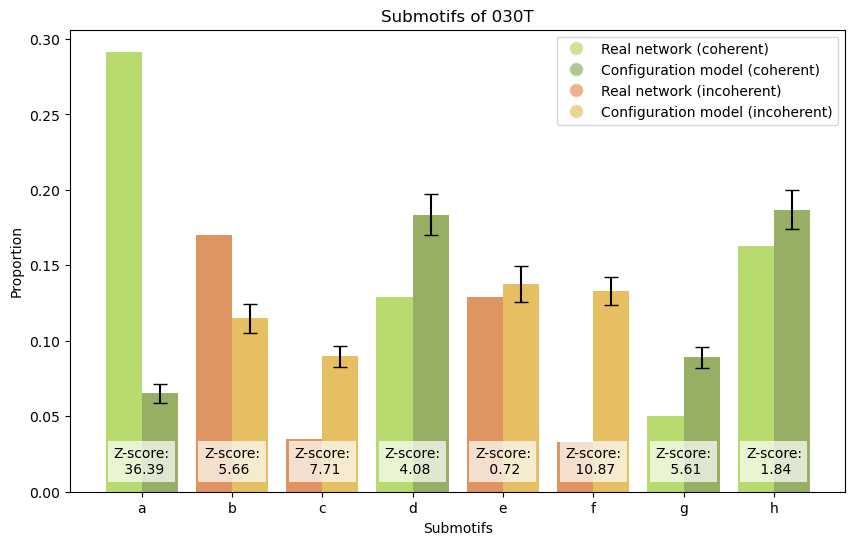

In [81]:
colors = {"a": "yellowgreen", "b": "chocolate", "c": "chocolate", "d": "yellowgreen", "e": "chocolate", "f": "chocolate", "g": "yellowgreen", "h": "yellowgreen"}
colors_config = {"a" : "olivedrab", "b": "goldenrod", "c": "goldenrod", "d": "olivedrab", "e": "goldenrod", "f": "goldenrod", "g": "olivedrab", "h": "olivedrab"}

total = sum(mean_submotifs.values())
mean_submotifs = {k: v / total for k, v in mean_submotifs.items()}
std_submotifs = {k: v / total for k, v in std_submotifs.items()}
total = sum(submotifs030T_real.values())
submotifs030T_real = {k: v / total for k, v in submotifs030T_real.items()}
z_scores_submotifs = {k: (submotifs030T_real[k] - mean_submotifs[k]) / std_submotifs[k] for k in submotifs030T_real.keys()}
x1 = np.arange(len(submotifs030T_real))
x2 = [x + 0.4 for x in x1]
plt.figure(figsize=(10, 6))
plt.bar(x1, list(submotifs030T_real.values()), width=0.4, alpha=0.7, color=[colors[k] for k in submotifs030T_real.keys()])
plt.bar(x2, list(mean_submotifs.values()), width=0.4, alpha=0.7, color=[colors_config[k] for k in mean_submotifs.keys()],
        yerr=[std_submotifs[k] for k in mean_submotifs.keys()], capsize=5)
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
real_patch1 = Line2D([0], [0], marker='o', color='w', label='Real network (coherent)',
                     markerfacecolor='yellowgreen', markersize=10, alpha=0.5)
config_patch1 = Line2D([0], [0], marker='o', color='w', label='Configuration model (coherent)',
                       markerfacecolor='olivedrab', markersize=10, alpha=0.5)
real_patch2 = Line2D([0], [0], marker='o', color='w', label='Real network (incoherent)',
                     markerfacecolor='chocolate', markersize=10, alpha=0.5)
config_patch2 = Line2D([0], [0], marker='o', color='w', label='Configuration model (incoherent)',
                       markerfacecolor='goldenrod', markersize=10, alpha=0.5)
plt.legend(handles=[real_patch1, config_patch1, real_patch2, config_patch2])
plt.xlabel("Submotifs")
plt.ylabel("Proportion")
plt.title("Submotifs of 030T")
plt.xticks([r + 0.2 for r in range(len(submotifs030T_real))], list(submotifs030T_real.keys()))
for i, k in enumerate(submotifs030T_real.keys()):
    plt.text(i + 0.2, 0.02, f'Z-score:\n {abs(z_scores_submotifs[k]):.2f}', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transData, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.show()